# Fuzzy Clustering Analysis - 20 Newsgroups

This notebook analyzes the semantic structure discovered by fuzzy clustering.

Key questions:
1. Are the clusters semantically meaningful?
2. What lives at cluster boundaries?
3. How do clusters relate to original categories?

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from clustering import FuzzyClusterer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## Load Data and Clustering Results

In [2]:
# Load cleaned dataset
df = pd.read_parquet('../data/processed/cleaned_newsgroups.parquet')
print(f"Loaded {len(df)} documents")

# Load clustering model
clusterer = FuzzyClusterer()

clusterer.load('../data/processed/fuzzy_clustering.pkl')
print(f"Loaded clustering with {clusterer.n_clusters} clusters")
print(f"Fuzzy Partition Coefficient: {clusterer.fpc:.4f}")

# Load membership matrix
u = np.load('../data/processed/membership_matrix.npy')
print(f"Membership matrix shape: {u.shape}")

Loaded 17821 documents
Loaded clustering model from ../data/processed/fuzzy_clustering.pkl
Loaded clustering with 18 clusters
Fuzzy Partition Coefficient: 0.0556
Membership matrix shape: (18, 17821)


## 1. Cluster Size Distribution

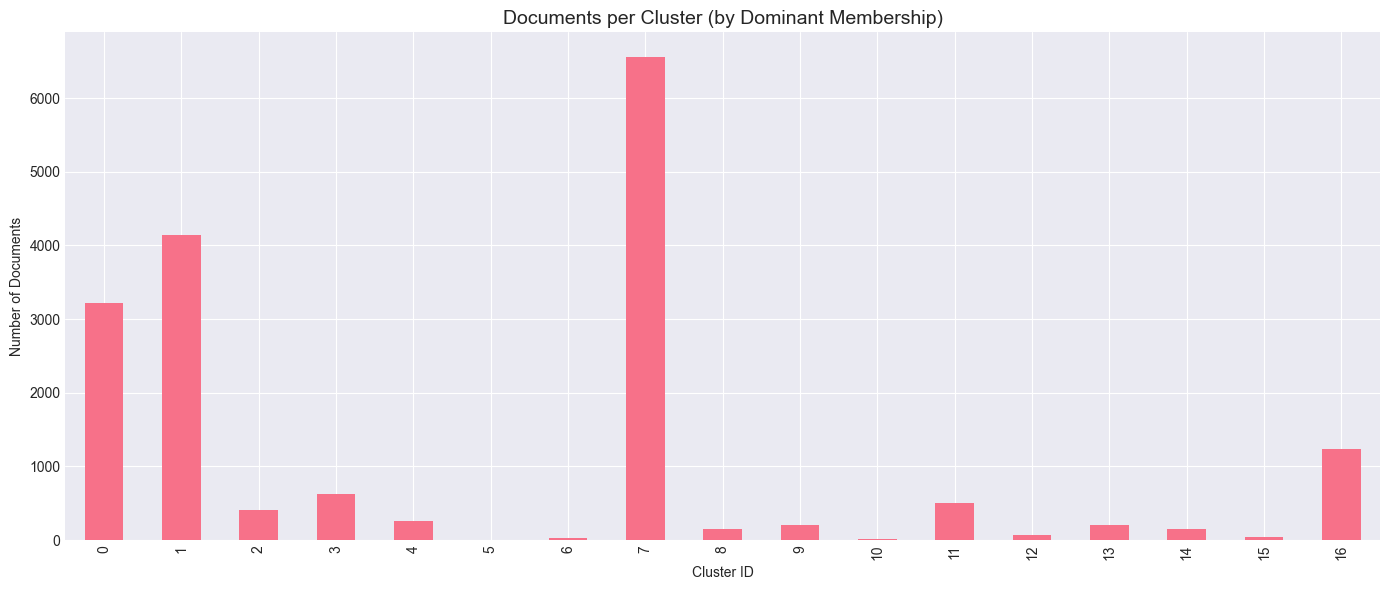

Average cluster size: 1048
Std deviation: 1845


In [3]:
# Get dominant clusters
dominant_clusters = np.argmax(u, axis=0)

# Count documents per cluster
cluster_sizes = pd.Series(dominant_clusters).value_counts().sort_index()

# Visualize
plt.figure(figsize=(14, 6))
cluster_sizes.plot(kind='bar')
plt.title('Documents per Cluster (by Dominant Membership)', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Number of Documents')
plt.tight_layout()
plt.show()

print(f"Average cluster size: {cluster_sizes.mean():.0f}")
print(f"Std deviation: {cluster_sizes.std():.0f}")

## 2. Cluster Composition vs Original Categories

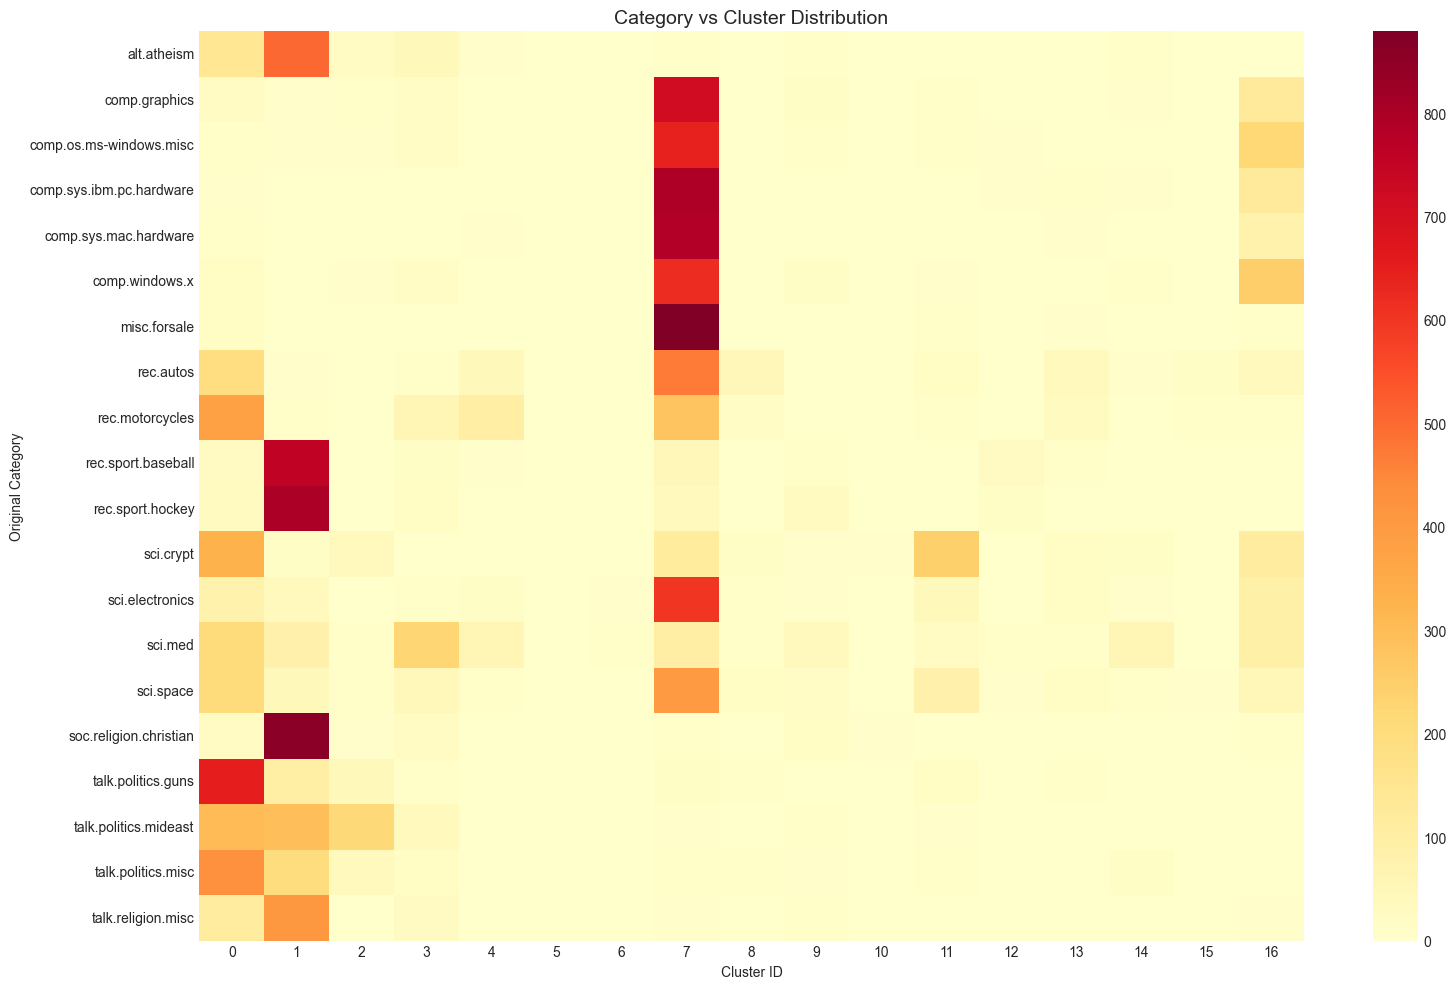

In [4]:
# Add dominant cluster to dataframe
df['dominant_cluster'] = dominant_clusters

# Create confusion matrix
confusion = pd.crosstab(df['category'], df['dominant_cluster'])

# Visualize
plt.figure(figsize=(16, 10))
sns.heatmap(confusion, cmap='YlOrRd', annot=False, fmt='d')
plt.title('Category vs Cluster Distribution', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Original Category')
plt.tight_layout()
plt.show()

## 3. Cluster Purity Analysis

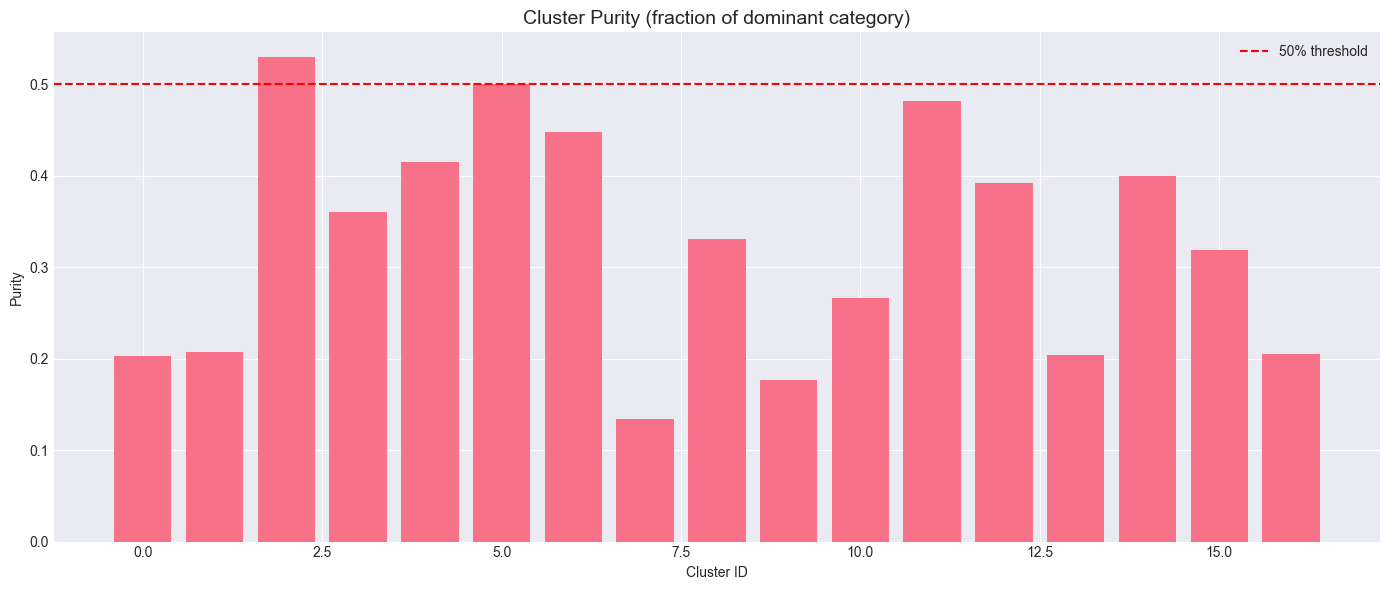

Average purity: 0.328
High purity clusters (>80%): 0


In [5]:
# For each cluster, find dominant category
cluster_purity = []

for cluster_id in range(clusterer.n_clusters):
    cluster_docs = df[df['dominant_cluster'] == cluster_id]
    if len(cluster_docs) > 0:
        # Find most common category
        top_category = cluster_docs['category'].value_counts().iloc[0]
        purity = top_category / len(cluster_docs)
        cluster_purity.append({
            'cluster_id': cluster_id,
            'size': len(cluster_docs),
            'purity': purity,
            'dominant_category': cluster_docs['category'].value_counts().index[0]
        })

purity_df = pd.DataFrame(cluster_purity)

# Visualize
plt.figure(figsize=(14, 6))
plt.bar(purity_df['cluster_id'], purity_df['purity'])
plt.axhline(y=0.5, color='r', linestyle='--', label='50% threshold')
plt.title('Cluster Purity (fraction of dominant category)', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Purity')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average purity: {purity_df['purity'].mean():.3f}")
print(f"High purity clusters (>80%): {len(purity_df[purity_df['purity'] > 0.8])}")

## 4. Membership Distribution Analysis

How 'fuzzy' are the assignments?

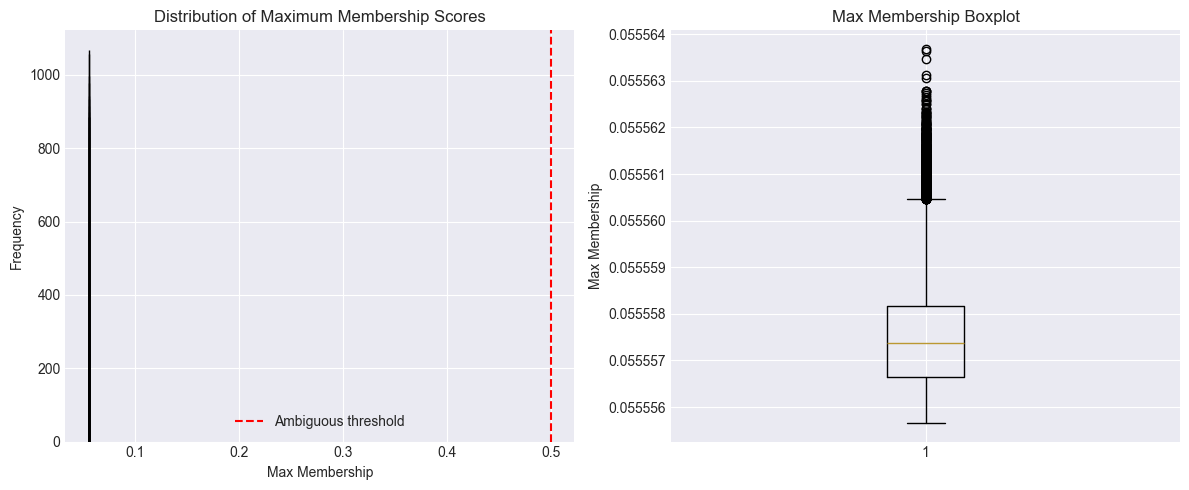

Mean max membership: 0.056
Documents with max membership < 0.5: 17821
Documents with max membership > 0.8: 0


In [6]:
# Get max membership for each document
max_memberships = np.max(u, axis=0)

# Visualize distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(max_memberships, bins=50, edgecolor='black')
plt.title('Distribution of Maximum Membership Scores')
plt.xlabel('Max Membership')
plt.ylabel('Frequency')
plt.axvline(x=0.5, color='r', linestyle='--', label='Ambiguous threshold')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(max_memberships)
plt.title('Max Membership Boxplot')
plt.ylabel('Max Membership')

plt.tight_layout()
plt.show()

print(f"Mean max membership: {max_memberships.mean():.3f}")
print(f"Documents with max membership < 0.5: {(max_memberships < 0.5).sum()}")
print(f"Documents with max membership > 0.8: {(max_memberships > 0.8).sum()}")

## 5. Boundary Documents - The Interesting Cases

Documents with significant membership in multiple clusters

In [7]:
# Find documents with split membership
def find_boundary_docs(threshold=0.25):
    boundary_docs = []
    
    for doc_idx in range(u.shape[1]):
        memberships = u[:, doc_idx]
        # Get top 3 clusters
        top_indices = np.argsort(memberships)[-3:][::-1]
        top_memberships = memberships[top_indices]
        
        # Check if at least 2 clusters have significant membership
        if top_memberships[1] > threshold:
            boundary_docs.append({
                'doc_idx': doc_idx,
                'cluster_1': top_indices[0],
                'membership_1': top_memberships[0],
                'cluster_2': top_indices[1],
                'membership_2': top_memberships[1],
                'cluster_3': top_indices[2],
                'membership_3': top_memberships[2],
                'text': df.iloc[doc_idx]['text'][:300]
            })
    
    return pd.DataFrame(boundary_docs)

boundary_df = find_boundary_docs(threshold=0.25)
print(f"Found {len(boundary_df)} boundary documents (>{0.25} membership in 2+ clusters)")

# Show some examples
print("\nExample boundary documents:")
for idx, row in boundary_df.head(5).iterrows():
    print(f"\nDocument {row['doc_idx']}:")
    print(f"  Cluster {row['cluster_1']}: {row['membership_1']:.3f}")
    print(f"  Cluster {row['cluster_2']}: {row['membership_2']:.3f}")
    print(f"  Cluster {row['cluster_3']}: {row['membership_3']:.3f}")
    print(f"  Text: {row['text'][:200]}...")

Found 0 boundary documents (>0.25 membership in 2+ clusters)

Example boundary documents:


## 6. Cluster Visualization (t-SNE)

Loading embeddings...
Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
Loaded 17821 embeddings
Running t-SNE (this may take a few minutes)...


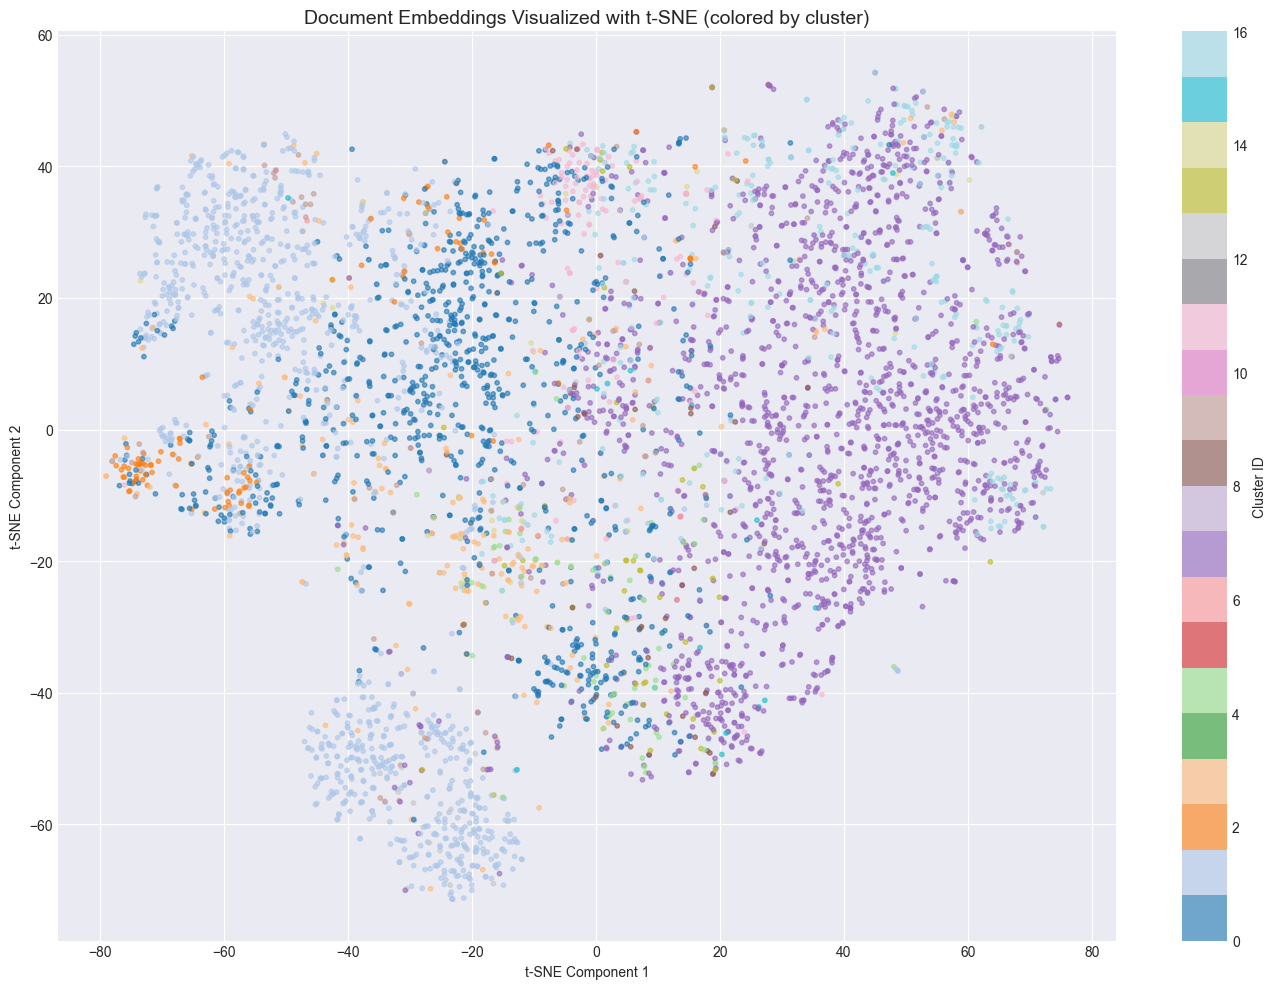

In [8]:
# This requires embeddings - load from vector DB
from embeddings import EmbeddingManager

print("Loading embeddings...")
em = EmbeddingManager(persist_directory='../data/processed/chroma_db')
embeddings_dict = em.get_all_embeddings()

# Convert to array
doc_ids = sorted(embeddings_dict.keys())
embeddings = np.array([embeddings_dict[doc_id] for doc_id in doc_ids])

print(f"Loaded {len(embeddings)} embeddings")
print("Running t-SNE (this may take a few minutes)...")

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings[:5000])  # Use subset for speed

# Visualize
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=dominant_clusters[:5000],
    cmap='tab20',
    alpha=0.6,
    s=10
)
plt.colorbar(scatter, label='Cluster ID')
plt.title('Document Embeddings Visualized with t-SNE (colored by cluster)', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

## 7. Top Terms per Cluster

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_terms(cluster_id, n_terms=10):
    """Get top terms for a cluster weighted by membership."""
    # Get documents in cluster
    cluster_docs = df[df['dominant_cluster'] == cluster_id]
    
    if len(cluster_docs) == 0:
        return []
    
    # Get memberships
    doc_indices = cluster_docs.index.tolist()
    memberships = [u[cluster_id, idx] for idx in doc_indices]
    
    # TF-IDF
    vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(cluster_docs['text'])
    feature_names = vectorizer.get_feature_names_out()
    
    # Weight by membership
    weighted_tfidf = tfidf_matrix.multiply(np.array(memberships).reshape(-1, 1))
    term_scores = np.array(weighted_tfidf.sum(axis=0)).flatten()
    
    # Get top terms
    top_indices = term_scores.argsort()[-n_terms:][::-1]
    return [(feature_names[i], term_scores[i]) for i in top_indices]

# Print top terms for each cluster
print("Top terms per cluster:\n")
for cluster_id in range(clusterer.n_clusters):
    terms = get_top_terms(cluster_id, n_terms=8)
    if terms:
        term_str = ', '.join([term for term, score in terms])
        size = cluster_sizes.get(cluster_id, 0)
        print(f"Cluster {cluster_id:2d} (n={size:4d}): {term_str}")

Top terms per cluster:

Cluster  0 (n=3220): just, people, don, like, know, think, time, did
Cluster  1 (n=4138): god, people, think, don, just, like, game, know
Cluster  2 (n= 413): people, don, government, just, like, israel, armenians, think
Cluster  3 (n= 624): don, like, just, time, think, does, people, know
Cluster  4 (n= 253): just, don, bike, good, think, like, know, car
Cluster  5 (n=   2): polio, coin, patients, canada, value, dollar, just, know
Cluster  6 (n=  29): good, just, need, like, does, probably, time, used
Cluster  7 (n=6566): like, know, thanks, just, does, use, new, don
Cluster  8 (n= 148): car, like, just, think, don, use, know, new
Cluster  9 (n= 209): just, know, thanks, like, ve, does, problem, mail
Cluster 10 (n=  15): secret, know, said, good, just, like, asked, ks
Cluster 11 (n= 506): use, key, people, like, just, don, know, space
Cluster 12 (n=  74): games, year, know, think, time, got, good, problem
Cluster 13 (n= 201): like, just, know, used, don, drive,

## 8. Entropy Analysis - Measuring Uncertainty

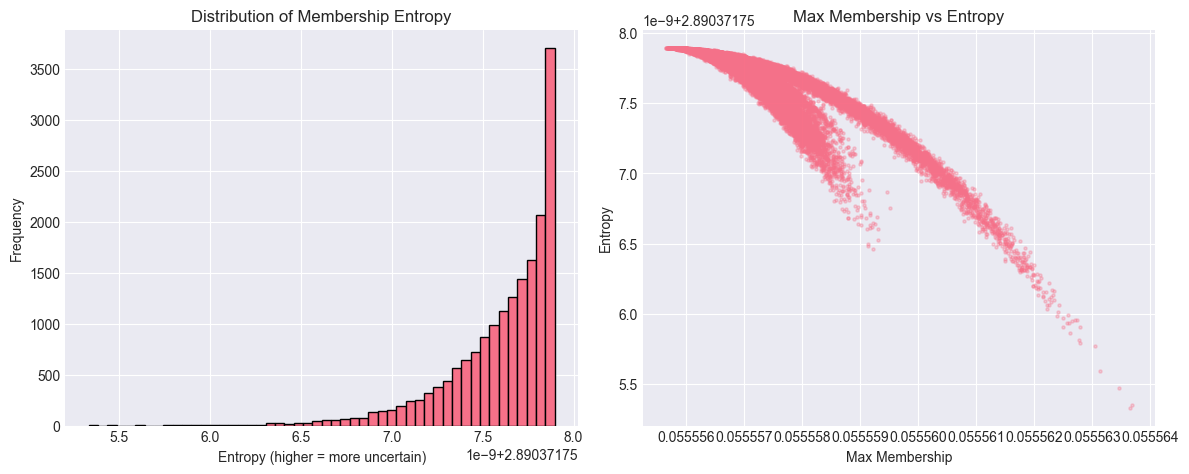

Mean entropy: 2.890
High entropy docs (>2.0): 17821

Most uncertain documents (high entropy):

Document 3152 (entropy=2.890):
  Cluster 4: 0.056
  Cluster 9: 0.056
  Cluster 0: 0.056
  Text: The screws are Torx screws and the tool isn't to hard to find. It's a matter of finding one with a long enough shaft to do the trick. No it is not a good idea to take that fan out. Why because it will...

Document 10803 (entropy=2.890):
  Cluster 13: 0.056
  Cluster 8: 0.056
  Cluster 16: 0.056
  Text: There's only one way I know of to tell an AR-15 from an M-16. Pick it up, hold it about a foot from your face and look closely at the saftey lever. If it has two positions, its an AR-15, if it has thr...

Document 9586 (entropy=2.890):
  Cluster 14: 0.056
  Cluster 6: 0.056
  Cluster 16: 0.056
  Text: I feel compelled to complain: the statement that recent observations rule out merging neutron stars as sources of gamma-ray bursts is utterly false, even though it is popular enough to make it to BATS..

In [11]:
from scipy.stats import entropy

# Calculate entropy for each document
entropies = []
for doc_idx in range(u.shape[1]):
    memberships = u[:, doc_idx]
    # Shannon entropy
    ent = entropy(memberships)
    entropies.append(ent)

entropies = np.array(entropies)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(entropies, bins=50, edgecolor='black')
plt.title('Distribution of Membership Entropy')
plt.xlabel('Entropy (higher = more uncertain)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.scatter(max_memberships, entropies, alpha=0.3, s=5)
plt.title('Max Membership vs Entropy')
plt.xlabel('Max Membership')
plt.ylabel('Entropy')

plt.tight_layout()
plt.show()

print(f"Mean entropy: {entropies.mean():.3f}")
print(f"High entropy docs (>2.0): {(entropies > 2.0).sum()}")

# Show most uncertain documents
most_uncertain = np.argsort(entropies)[-5:][::-1]
print("\nMost uncertain documents (high entropy):")
for idx in most_uncertain:
    memberships = u[:, idx]
    top_clusters = np.argsort(memberships)[-3:][::-1]
    print(f"\nDocument {idx} (entropy={entropies[idx]:.3f}):")
    for cluster_id in top_clusters:
        print(f"  Cluster {cluster_id}: {memberships[cluster_id]:.3f}")
    print(f"  Text: {df.iloc[idx]['text'][:200]}...")

## Conclusion

This analysis demonstrates:

1. **Semantic Meaning**: Clusters capture meaningful topics through term analysis
2. **Soft Boundaries**: Many documents have split membership (boundary cases)
3. **Structure**: Clear relationship between clusters and original categories
4. **Uncertainty**: High-entropy documents represent genuinely ambiguous content

The fuzzy clustering successfully uncovers the messy, overlapping semantic structure of real-world text data.